In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports done!")
print(f"Pandas version: {pd.__version__}")

All imports done!
Pandas version: 2.2.2


In [26]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (7043, 21)

First look:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


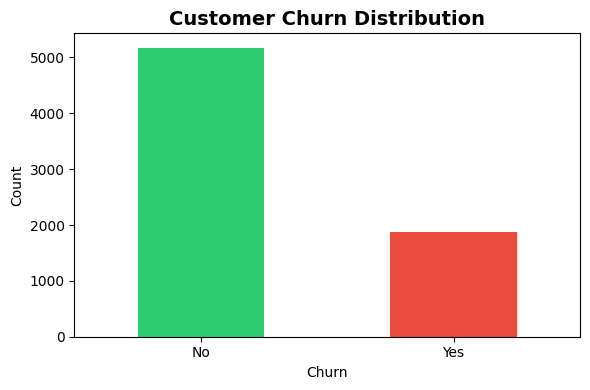

Chart saved!


In [29]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', color=colors)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

<Figure size 800x500 with 0 Axes>

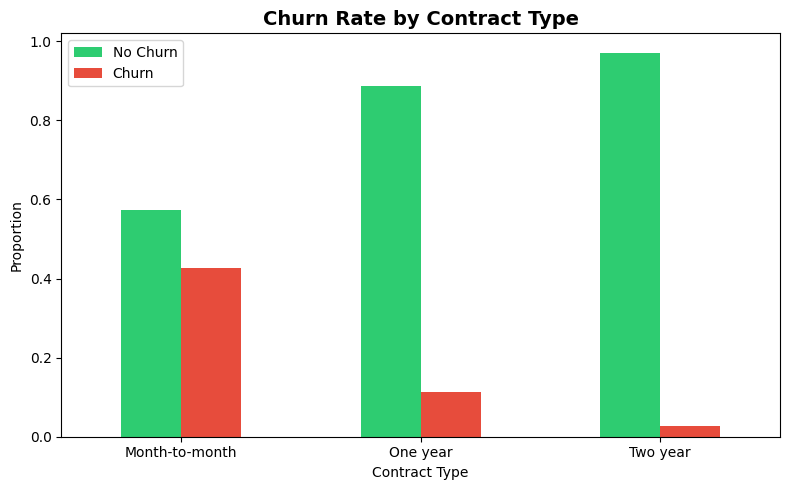

In [30]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], figsize=(8, 5))
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', bbox_inches='tight')
plt.show()

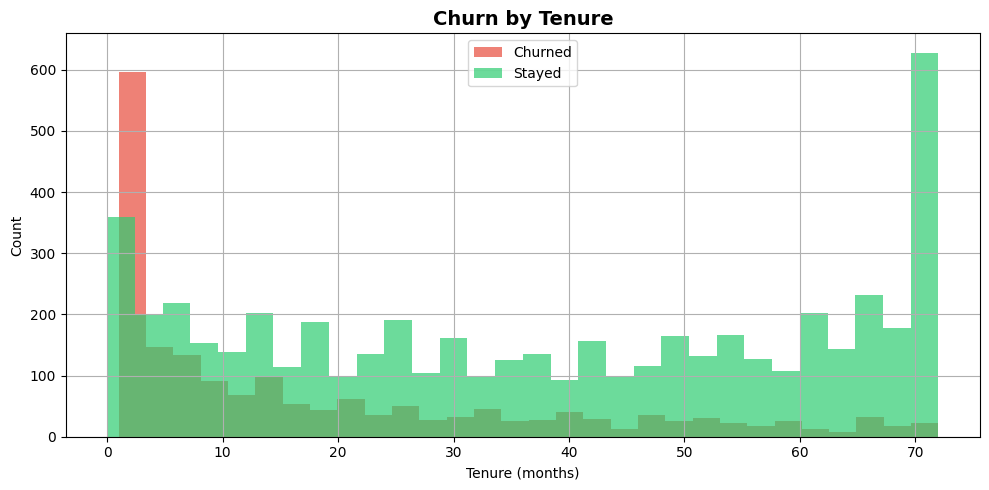

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7,
                                      color='#e74c3c',
                                      label='Churned', ax=ax)
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7,
                                     color='#2ecc71',
                                     label='Stayed', ax=ax)
ax.set_title('Churn by Tenure', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('churn_by_tenure.png', bbox_inches='tight')
plt.show()

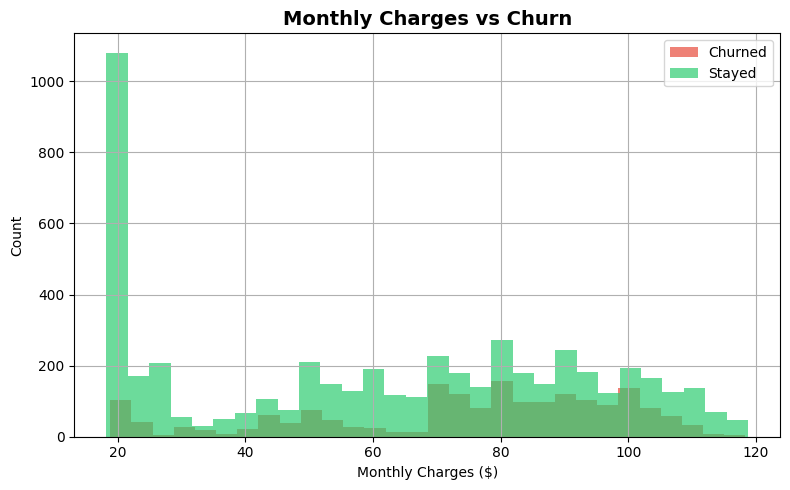

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df['Churn']=='Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, color='#e74c3c', label='Churned', ax=ax)
df[df['Churn']=='No']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, color='#2ecc71', label='Stayed', ax=ax)
ax.set_title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('churn_by_charges.png', bbox_inches='tight')
plt.show()

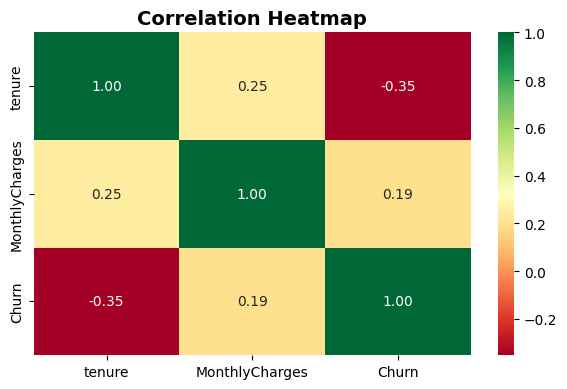

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
numerical_cols = ['tenure', 'MonthlyCharges']
corr_data = df[numerical_cols + ['Churn']].copy()
corr_data['Churn'] = corr_data['Churn'].map({'Yes': 1, 'No': 0})
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [34]:
print("Before fix:")
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))

Before fix:
object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [35]:
# Convert to numeric — spaces become NaN!
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("NaN count:", df['TotalCharges'].isnull().sum())
print("dtype now:", df['TotalCharges'].dtype)

NaN count: 11
dtype now: float64


In [36]:
df = df.dropna()
print("Shape after dropping NaN:", df.shape)
print("TotalCharges dtype:", df['TotalCharges'].dtype)

Shape after dropping NaN: (7032, 21)
TotalCharges dtype: float64


In [37]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn encoded:")
print(df['Churn'].value_counts())
print("dtype:", df['Churn'].dtype)

Churn encoded:
Churn
0    5163
1    1869
Name: count, dtype: int64
dtype: int64


In [38]:
# Drop customerID — useless for model!
df = df.drop('customerID', axis=1)

# Get dummies for all object columns!
df = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())

Shape after encoding: (7032, 31)
Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Features shape: (7032, 30)
Target shape: (7032,)

Train size: (5625, 30)
Test size: (1407, 30)

Train churn rate: 0.266
Test churn rate: 0.266


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on TRAIN only!
X_test_scaled  = scaler.transform(X_test)        # transform only!

print("Scaling done!")
print("Train mean (should be ~0):", X_train_scaled.mean().round(3))
print("Train std  (should be ~1):", X_train_scaled.std().round(3))

Scaling done!
Train mean (should be ~0): -0.0
Train std  (should be ~1): 1.0


In [41]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

Logistic Regression trained!


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score

# Get probabilities first
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Explicit threshold — business decision!
threshold = 0.4
y_pred_lr = (y_prob_lr >= threshold).astype(int)

print("Logistic Regression Results:")
print("="*40)
print(classification_report(y_test, y_pred_lr,
      target_names=['Stay', 'Churn']))

print("\n🎯 Key Metric: RECALL")
print("Reason: Missing a churner is costly compared to false alarms.")
print(f"Recall achieved: {recall_score(y_test, y_pred_lr):.3f}")
print(f"At threshold=0.4: catching {int(recall_score(y_test, y_pred_lr)*100)}% of actual churners!")

Logistic Regression Results:
              precision    recall  f1-score   support

        Stay       0.93      0.62      0.74      1033
       Churn       0.45      0.87      0.60       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.70      1407


🎯 Key Metric: RECALL
Reason: Missing a churner is costly compared to false alarms.
Recall achieved: 0.872
At threshold=0.4: catching 87% of actual churners!


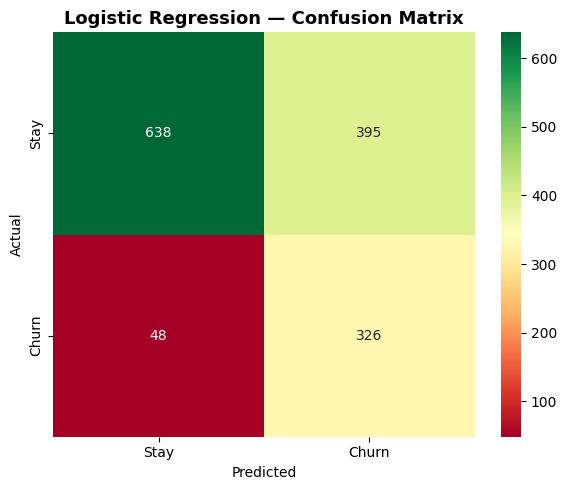

TP=326 | TN=638 | FP=395 | FN=48

Business Reading:
Churners caught (TP):     326
Churners missed (FN):     48 ← dangerous!
False alarms (FP):        395 ← wasted calls
Correct stays (TN):       638


In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d',
            cmap='RdYlGn',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'],
            ax=ax)
ax.set_title('Logistic Regression — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_logistic.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"TP={tp} | TN={tn} | FP={fp} | FN={fn}")
print(f"\nBusiness Reading:")
print(f"Churners caught (TP):     {tp}")
print(f"Churners missed (FN):     {fn} ← dangerous!")
print(f"False alarms (FP):        {fp} ← wasted calls")
print(f"Correct stays (TN):       {tn}")

In [44]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)
print("Decision Tree trained!")

Decision Tree trained!


In [45]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results:")
print("="*40)
print(classification_report(y_test, y_pred_dt,
      target_names=['Stay', 'Churn']))

Decision Tree Results:
              precision    recall  f1-score   support

        Stay       0.90      0.68      0.77      1033
       Churn       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407



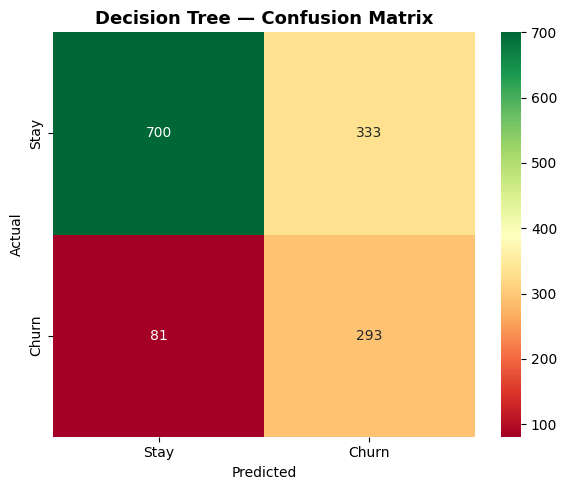

TP=293 | TN=700 | FP=333 | FN=81
Churners caught: 293
Churners missed: 81 ← dangerous!


In [46]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d',
            cmap='RdYlGn',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'],
            ax=ax)
ax.set_title('Decision Tree — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_decision_tree.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"TP={tp} | TN={tn} | FP={fp} | FN={fn}")
print(f"Churners caught: {tp}")
print(f"Churners missed: {fn} ← dangerous!")

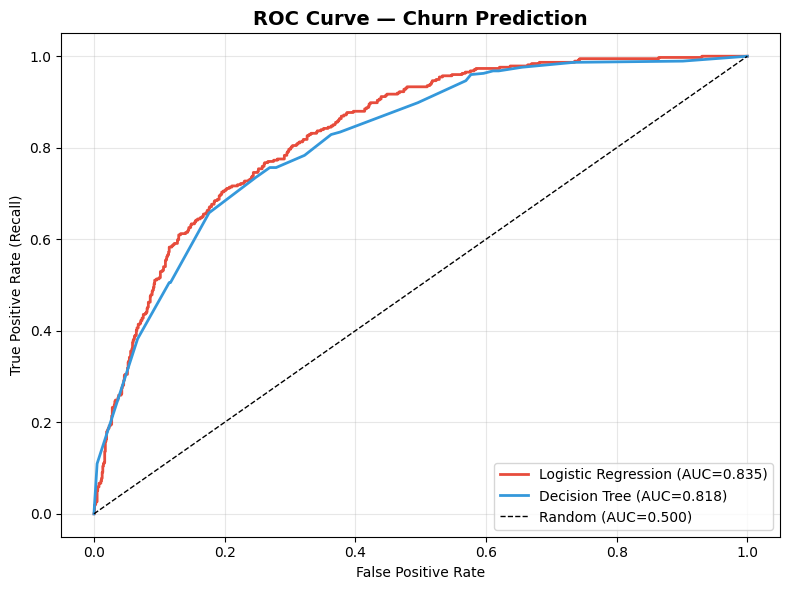

LR  AUC: 0.8350
DT  AUC: 0.8179


In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, color='#e74c3c',
        linewidth=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
ax.plot(fpr_dt, tpr_dt, color='#3498db',
        linewidth=2, label=f'Decision Tree (AUC={auc_dt:.3f})')

# Random baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Churn Prediction',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

print(f"LR  AUC: {auc_lr:.4f}")
print(f"DT  AUC: {auc_dt:.4f}")

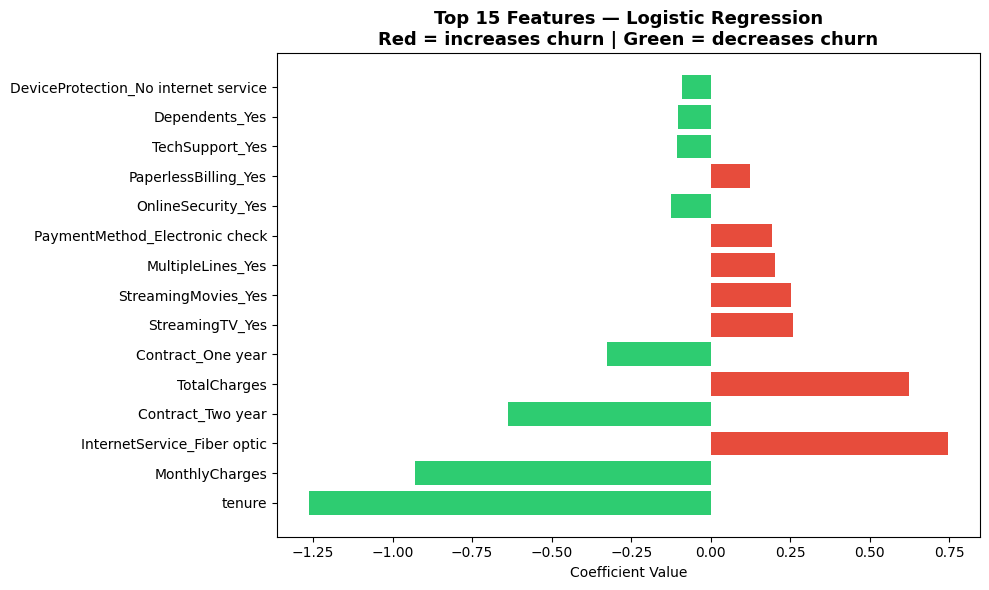

Top 5 churn drivers:
                        feature  coefficient
1                        tenure    -1.263854
2                MonthlyCharges    -0.928682
10  InternetService_Fiber optic     0.746144
25            Contract_Two year    -0.638598
3                  TotalCharges     0.623279


In [48]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_[0]
})
coef_df = coef_df.reindex(
    coef_df['coefficient'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in coef_df['coefficient'][:15]]
ax.barh(coef_df['feature'][:15],
        coef_df['coefficient'][:15], color=colors)
ax.set_title('Top 15 Features — Logistic Regression\n'
             'Red = increases churn | Green = decreases churn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 churn drivers:")
print(coef_df.head(5)[['feature', 'coefficient']])

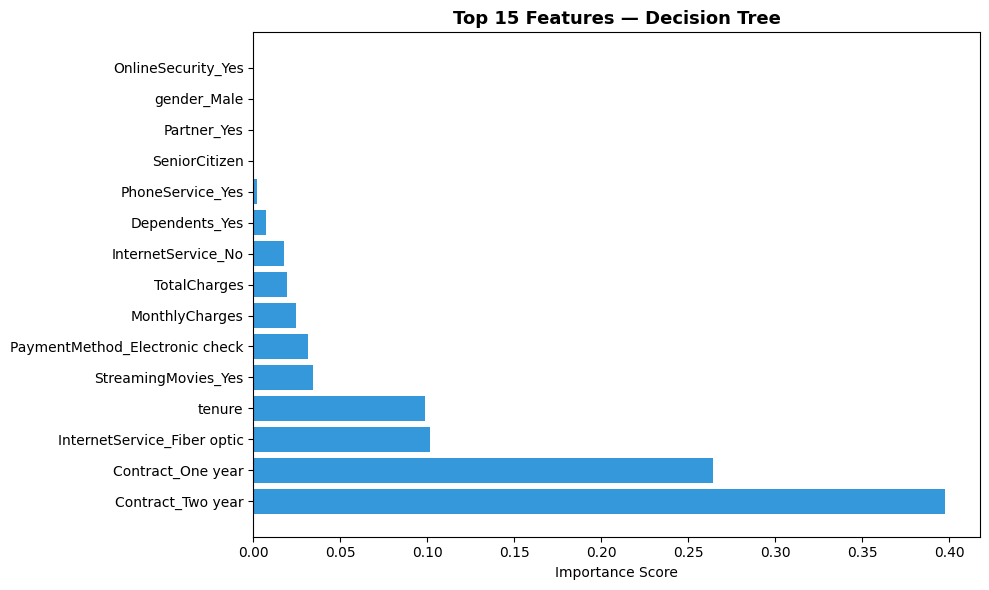

Top 5 features:
                        feature  importance
25            Contract_Two year    0.397662
24            Contract_One year    0.264054
10  InternetService_Fiber optic    0.101743
1                        tenure    0.098646
23          StreamingMovies_Yes    0.034495


In [49]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_model.feature_importances_
})
importance_df = importance_df.sort_values(
    'importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'],
        importance_df['importance'],
        color='#3498db')
ax.set_title('Top 15 Features — Decision Tree',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(importance_df.head(5))

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("FINAL MODEL COMPARISON")
print("="*55)
print(f"{'Metric':<20} {'Log Reg':>15} {'Dec Tree':>15}")
print("-"*55)
print(f"{'Precision':<20} {precision_score(y_test, y_pred_lr):>15.4f} {precision_score(y_test, y_pred_dt):>15.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_lr):>15.4f} {recall_score(y_test, y_pred_dt):>15.4f}")
print(f"{'F1 Score':<20} {f1_score(y_test, y_pred_lr):>15.4f} {f1_score(y_test, y_pred_dt):>15.4f}")
print(f"{'ROC-AUC':<20} {auc_lr:>15.4f} {auc_dt:>15.4f}")
print("="*55)
print("\n✅ Primary model: Logistic Regression")
print("   Reason: Higher Recall = catches more churners!")
print("   Missing churner = ₹5000 lost")
print("   False alarm     = ₹500 wasted (10x cheaper!)")

FINAL MODEL COMPARISON
Metric                       Log Reg        Dec Tree
-------------------------------------------------------
Precision                     0.4521          0.4681
Recall                        0.8717          0.7834
F1 Score                      0.5954          0.5860
ROC-AUC                       0.8350          0.8179

✅ Primary model: Logistic Regression
   Reason: Higher Recall = catches more churners!
   Missing churner = ₹5000 lost
   False alarm     = ₹500 wasted (10x cheaper!)


In [51]:
total_test     = len(y_test)         # 1407
actual_churners = y_test.sum()       # actual churners in test

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
caught       = tp
missed       = fn
false_alarms = fp

revenue_per_churner = 5000  # ₹ lost if churner leaves
retention_call_cost = 500   # ₹ cost per retention call

revenue_saved  = caught * revenue_per_churner
revenue_lost   = missed * revenue_per_churner
call_cost      = (caught + false_alarms) * retention_call_cost
net_benefit    = revenue_saved - revenue_lost - call_cost

print("BUSINESS IMPACT ANALYSIS")
print("="*45)
print(f"Churners caught:      {caught}")
print(f"Churners missed:      {missed}")
print(f"Revenue saved:        ₹{revenue_saved:,}")
print(f"Revenue lost:         ₹{revenue_lost:,}")
print(f"Retention call cost:  ₹{call_cost:,}")
print(f"Net benefit:          ₹{net_benefit:,}")
print("="*45)

BUSINESS IMPACT ANALYSIS
Churners caught:      326
Churners missed:      48
Revenue saved:        ₹1,630,000
Revenue lost:         ₹240,000
Retention call cost:  ₹360,500
Net benefit:          ₹1,029,500


In [52]:
import pickle
import os

# Save to models/ folder
os.makedirs('models', exist_ok=True)

with open('models/model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names too!
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Models saved!")
print("✅ models/model.pkl")
print("✅ models/scaler.pkl")
print("✅ models/feature_names.pkl")

Models saved!
✅ models/model.pkl
✅ models/scaler.pkl
✅ models/feature_names.pkl


In [33]:
from google.colab import files

# Download models
files.download('models/model.pkl')
files.download('models/scaler.pkl')
files.download('models/feature_names.pkl')

# Download screenshots
files.download('churn_distribution.png')
files.download('churn_by_contract.png')
files.download('churn_by_tenure.png')
files.download('churn_by_charges.png')
files.download('correlation_heatmap.png')
files.download('cm_logistic.png')
files.download('cm_decision_tree.png')
files.download('roc_curve.png')
files.download('lr_feature_importance.png')
files.download('dt_feature_importance.png')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
